In [2]:
import pandas as pd

# Nama file CSV yang ingin digabungkan
csv1 = "dataset_no_duplicates.csv"
csv2 = "datasethoaks_bersih.csv"

# Load kedua file
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)

# Gabungkan (concat)
df_combined = pd.concat([df1, df2], ignore_index=True)

# Simpan hasil gabungan ke file baru
df_combined.to_csv("datasetgabungan.csv", index=False)

print("✅ Dua dataset berhasil digabungkan dan disimpan ke datasetgabungan.csv")

✅ Dua dataset berhasil digabungkan dan disimpan ke datasetgabungan.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv("datasetgabungan.csv")

# # Bersihkan nilai aneh di kolom label (opsional kalau memang ada)
# df['label_validator'] = df['label_validator'].replace({'-': '0', ' ': '0', '0\\': '0'})

# Pastikan tipe data integer
if df['Label_Validator'].dtype != 'int':
    df['Label_Validator'] = df['Label_Validator'].astype(float).astype(int)

print("✅ Tipe data kolom Label_Validator:", df['Label_Validator'].dtype)
print("✅ Nilai unik label:", df['Label_Validator'].unique())

# =========================
# Distribusi awal sebelum undersampling
# =========================
print("\n=== Distribusi Awal (Sebelum Undersampling) ===")
print(df['Label_Validator'].value_counts())

# =========================
# Fungsi untuk undersampling kelas 0
# =========================
import os

def undersample_class0(df, target_size, save_dir):
    df_0 = df[df['Label_Validator'] == 0]
    df_other = df[df['Label_Validator'] != 0]

    # Ambil sampel dari kelas 0 sebesar target_size
    df_0_sampled = df_0.sample(n=target_size, random_state=42)

    # Gabungkan kembali
    df_balanced = pd.concat([df_0_sampled, df_other], ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # =========================
    # Distribusi setelah undersampling
    # =========================
    print(f"\n=== Distribusi Setelah Undersampling (kelas 0 = {target_size}) ===")
    print(df_balanced['Label_Validator'].value_counts())

    # Split train (70%), val (15%), test (15%)
    train_df, temp_df = train_test_split(
        df_balanced,
        test_size=0.3,
        stratify=df_balanced['Label_Validator'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['Label_Validator'],
        random_state=42
    )

    # Cek distribusi tiap split
    print(f"\n--- Split Dataset (kelas 0 = {target_size}) ---")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Distribusi Train:\n", train_df['Label_Validator'].value_counts())
    print("Distribusi Val:\n", val_df['Label_Validator'].value_counts())
    print("Distribusi Test:\n", test_df['Label_Validator'].value_counts())

    # Pastikan direktori ada
    os.makedirs(save_dir, exist_ok=True)

    # Save hasil
    train_df.to_csv(f"{save_dir}/train.csv", index=False)
    val_df.to_csv(f"{save_dir}/val.csv", index=False)
    test_df.to_csv(f"{save_dir}/test.csv", index=False)

# Jalankan untuk 30k, 20k, dan 10k
undersample_class0(df, 30000, "undersample_30k")
# undersample_class0(df, 20000, "undersample_20k")
# undersample_class0(df, 10000, "undersample_10k")


✅ Tipe data kolom Label_Validator: int32
✅ Nilai unik label: [1 5 3 0 4 2]

=== Distribusi Awal (Sebelum Undersampling) ===
Label_Validator
0    48172
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

=== Distribusi Setelah Undersampling (kelas 0 = 30000) ===
Label_Validator
0    30000
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

--- Split Dataset (kelas 0 = 30000) ---
Train: 32097, Val: 6878, Test: 6879
Distribusi Train:
 Label_Validator
0    21000
3     3636
1     2491
5     2488
4     2248
2      234
Name: count, dtype: int64
Distribusi Val:
 Label_Validator
0    4500
3     779
5     534
1     533
4     482
2      50
Name: count, dtype: int64
Distribusi Test:
 Label_Validator
0    4500
3     780
1     534
5     533
4     482
2      50
Name: count, dtype: int64


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv("dataset_no_duplicates.csv")

# # Bersihkan nilai aneh di kolom label (opsional kalau memang ada)
# df['label_validator'] = df['label_validator'].replace({'-': '0', ' ': '0', '0\\': '0'})

# Pastikan tipe data integer
if df['Label_Validator'].dtype != 'int':
    df['Label_Validator'] = df['Label_Validator'].astype(float).astype(int)

print("✅ Tipe data kolom Label_Validator:", df['Label_Validator'].dtype)
print("✅ Nilai unik label:", df['Label_Validator'].unique())

# =========================
# Distribusi awal sebelum undersampling
# =========================
print("\n=== Distribusi Awal (Sebelum Undersampling) ===")
print(df['Label_Validator'].value_counts())

# =========================
# Fungsi untuk undersampling kelas 0
# =========================
import os

def undersample_class0(df, target_size, save_dir):
    df_0 = df[df['Label_Validator'] == 0]
    df_other = df[df['Label_Validator'] != 0]

    # Ambil sampel dari kelas 0 sebesar target_size
    df_0_sampled = df_0.sample(n=target_size, random_state=42)

    # Gabungkan kembali
    df_balanced = pd.concat([df_0_sampled, df_other], ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # =========================
    # Distribusi setelah undersampling
    # =========================
    print(f"\n=== Distribusi Setelah Undersampling (kelas 0 = {target_size}) ===")
    print(df_balanced['Label_Validator'].value_counts())

    # Split train (70%), val (15%), test (15%)
    train_df, temp_df = train_test_split(
        df_balanced,
        test_size=0.3,
        stratify=df_balanced['Label_Validator'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['Label_Validator'],
        random_state=42
    )

    # Cek distribusi tiap split
    print(f"\n--- Split Dataset (kelas 0 = {target_size}) ---")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Distribusi Train:\n", train_df['Label_Validator'].value_counts())
    print("Distribusi Val:\n", val_df['Label_Validator'].value_counts())
    print("Distribusi Test:\n", test_df['Label_Validator'].value_counts())

    # Pastikan direktori ada
    os.makedirs(save_dir, exist_ok=True)

    # Save hasil
    train_df.to_csv(f"{save_dir}/train.csv", index=False)
    val_df.to_csv(f"{save_dir}/val.csv", index=False)
    test_df.to_csv(f"{save_dir}/test.csv", index=False)

# Jalankan untuk 30k, 20k, dan 10k
# undersample_class0(df, 30000, "undersample_30k")
undersample_class0(df, 20000, "undersample_20k")
# undersample_class0(df, 10000, "undersample_10k")


✅ Tipe data kolom Label_Validator: int32
✅ Nilai unik label: [1 5 3 0 4 2]

=== Distribusi Awal (Sebelum Undersampling) ===
Label_Validator
0    48172
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

=== Distribusi Setelah Undersampling (kelas 0 = 20000) ===
Label_Validator
0    20000
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

--- Split Dataset (kelas 0 = 20000) ---
Train: 25097, Val: 5378, Test: 5379
Distribusi Train:
 Label_Validator
0    14000
3     3636
1     2491
5     2488
4     2248
2      234
Name: count, dtype: int64
Distribusi Val:
 Label_Validator
0    3000
3     779
5     534
1     533
4     482
2      50
Name: count, dtype: int64
Distribusi Test:
 Label_Validator
0    3000
3     780
1     534
5     533
4     482
2      50
Name: count, dtype: int64


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv("dataset_no_duplicates.csv")

# # Bersihkan nilai aneh di kolom label (opsional kalau memang ada)
# df['label_validator'] = df['label_validator'].replace({'-': '0', ' ': '0', '0\\': '0'})

# Pastikan tipe data integer
if df['Label_Validator'].dtype != 'int':
    df['Label_Validator'] = df['Label_Validator'].astype(float).astype(int)

print("✅ Tipe data kolom Label_Validator:", df['Label_Validator'].dtype)
print("✅ Nilai unik label:", df['Label_Validator'].unique())

# =========================
# Distribusi awal sebelum undersampling
# =========================
print("\n=== Distribusi Awal (Sebelum Undersampling) ===")
print(df['Label_Validator'].value_counts())

# =========================
# Fungsi untuk undersampling kelas 0
# =========================
import os

def undersample_class0(df, target_size, save_dir):
    df_0 = df[df['Label_Validator'] == 0]
    df_other = df[df['Label_Validator'] != 0]

    # Ambil sampel dari kelas 0 sebesar target_size
    df_0_sampled = df_0.sample(n=target_size, random_state=42)

    # Gabungkan kembali
    df_balanced = pd.concat([df_0_sampled, df_other], ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # =========================
    # Distribusi setelah undersampling
    # =========================
    print(f"\n=== Distribusi Setelah Undersampling (kelas 0 = {target_size}) ===")
    print(df_balanced['Label_Validator'].value_counts())

    # Split train (70%), val (15%), test (15%)
    train_df, temp_df = train_test_split(
        df_balanced,
        test_size=0.3,
        stratify=df_balanced['Label_Validator'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['Label_Validator'],
        random_state=42
    )

    # Cek distribusi tiap split
    print(f"\n--- Split Dataset (kelas 0 = {target_size}) ---")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Distribusi Train:\n", train_df['Label_Validator'].value_counts())
    print("Distribusi Val:\n", val_df['Label_Validator'].value_counts())
    print("Distribusi Test:\n", test_df['Label_Validator'].value_counts())

    # Pastikan direktori ada
    os.makedirs(save_dir, exist_ok=True)

    # Save hasil
    train_df.to_csv(f"{save_dir}/train.csv", index=False)
    val_df.to_csv(f"{save_dir}/val.csv", index=False)
    test_df.to_csv(f"{save_dir}/test.csv", index=False)

# Jalankan untuk 30k, 20k, dan 10k
# undersample_class0(df, 30000, "undersample_30k")
# undersample_class0(df, 20000, "undersample_20k")
undersample_class0(df, 10000, "undersample_10k")


✅ Tipe data kolom Label_Validator: int32
✅ Nilai unik label: [1 5 3 0 4 2]

=== Distribusi Awal (Sebelum Undersampling) ===
Label_Validator
0    48172
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

=== Distribusi Setelah Undersampling (kelas 0 = 10000) ===
Label_Validator
0    10000
3     5195
1     3558
5     3555
4     3212
2      334
Name: count, dtype: int64

--- Split Dataset (kelas 0 = 10000) ---
Train: 18097, Val: 3878, Test: 3879
Distribusi Train:
 Label_Validator
0    7000
3    3636
1    2491
5    2488
4    2248
2     234
Name: count, dtype: int64
Distribusi Val:
 Label_Validator
0    1500
3     779
5     534
1     533
4     482
2      50
Name: count, dtype: int64
Distribusi Test:
 Label_Validator
0    1500
3     780
1     534
5     533
4     482
2      50
Name: count, dtype: int64


In [10]:
folders_to_zip = ["undersample_30k", "undersample_20k", "undersample_10k"]
zip_filename = "undersample_all.zip"

# Import untuk zip
import zipfile
import os

# Fungsi untuk zip multiple folders
def zip_folders(folders, zip_name):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for folder in folders:
            if os.path.exists(folder):
                for root, dirs, files in os.walk(folder):
                    for file in files:
                        file_path = os.path.join(root, file)
                        arcname = os.path.relpath(file_path, os.path.dirname(folder))
                        zipf.write(file_path, arcname)
                print(f"✅ Folder {folder} ditambahkan ke {zip_name}")
            else:
                print(f"⚠️ Folder {folder} tidak ditemukan")

# Jalankan zip
zip_folders(folders_to_zip, zip_filename)
print(f"✅ Semua folder dizip ke {zip_filename}") 

✅ Folder undersample_30k ditambahkan ke undersample_all.zip
✅ Folder undersample_20k ditambahkan ke undersample_all.zip
✅ Folder undersample_10k ditambahkan ke undersample_all.zip
✅ Semua folder dizip ke undersample_all.zip
✅ Folder undersample_20k ditambahkan ke undersample_all.zip
✅ Folder undersample_10k ditambahkan ke undersample_all.zip
✅ Semua folder dizip ke undersample_all.zip


In [ ]:
import zipfile

zip_filename = "undersample_all.zip"

# Ekstrak isi zip ke current directory
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall()  # default: ekstrak ke folder saat ini

print(f"✅ File {zip_filename} berhasil diekstrak ke current directory")


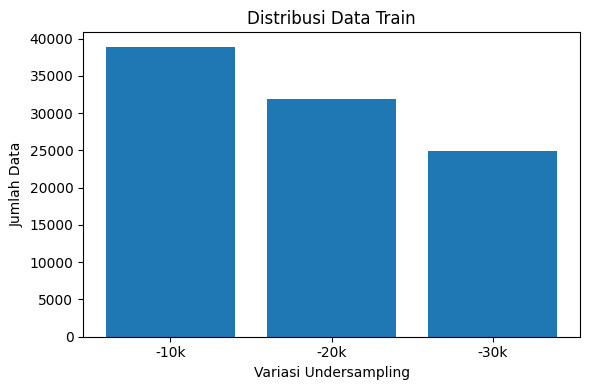

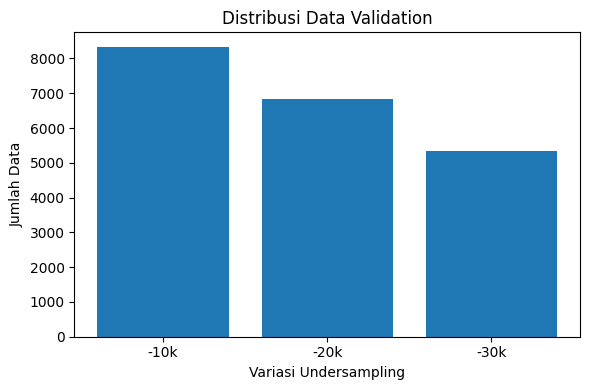

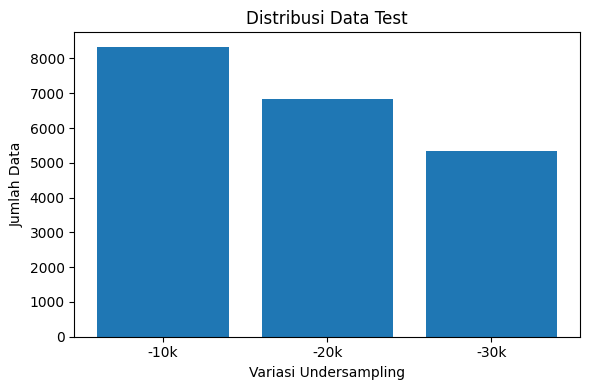

In [1]:
import matplotlib.pyplot as plt

# Data dari pengguna
datasets = ["-10k", "-20k", "-30k"]
train = [38892, 31892, 24892]
val = [8334, 6834, 5334]
test = [8334, 6834, 5334]

# Plot Train
plt.figure(figsize=(6,4))
plt.bar(datasets, train)
plt.title("Distribusi Data Train")
plt.xlabel("Variasi Undersampling")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

# Plot Validation
plt.figure(figsize=(6,4))
plt.bar(datasets, val)
plt.title("Distribusi Data Validation")
plt.xlabel("Variasi Undersampling")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

# Plot Test
plt.figure(figsize=(6,4))
plt.bar(datasets, test)
plt.title("Distribusi Data Test")
plt.xlabel("Variasi Undersampling")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()


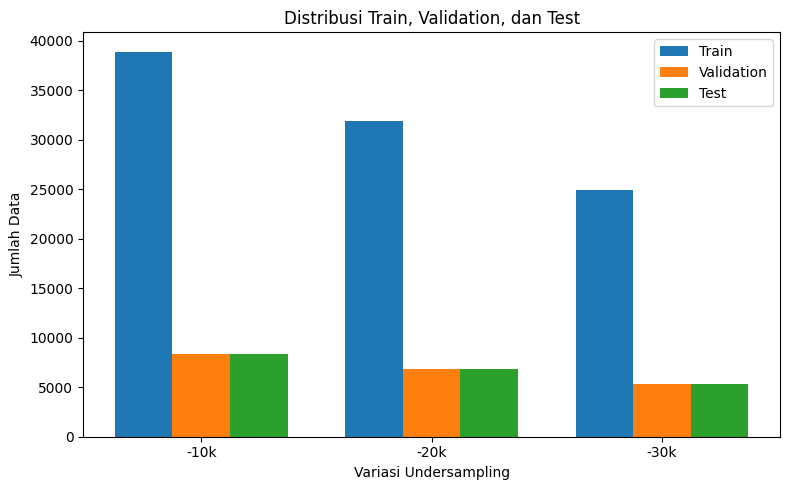

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["-10k", "-20k", "-30k"]
train = np.array([38892, 31892, 24892])
val = np.array([8334, 6834, 5334])
test = np.array([8334, 6834, 5334])

# Set posisi bar
x = np.arange(len(datasets))
width = 0.25  # lebar bar

plt.figure(figsize=(8,5))

# Bar chart
plt.bar(x - width, train, width, label="Train")
plt.bar(x, val, width, label="Validation")
plt.bar(x + width, test, width, label="Test")

# Label sumbu dan judul
plt.xticks(x, datasets)
plt.xlabel("Variasi Undersampling")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Train, Validation, dan Test")

plt.legend()
plt.tight_layout()
plt.show()


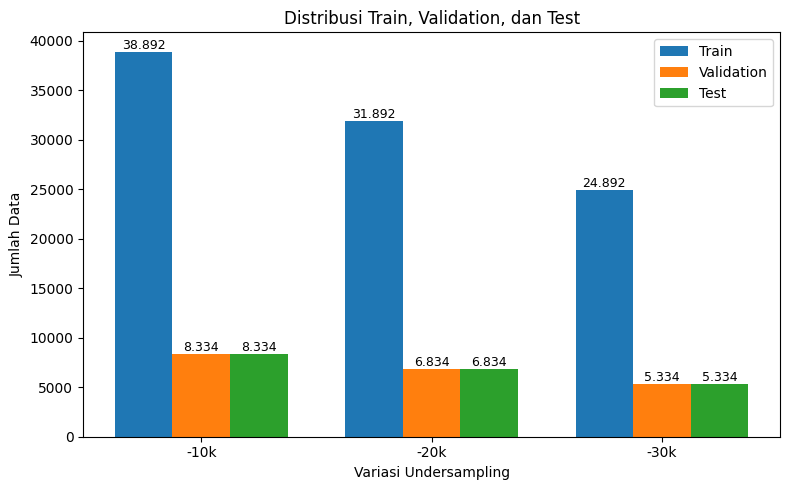

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["-10k", "-20k", "-30k"]
train = np.array([38892, 31892, 24892])
val = np.array([8334, 6834, 5334])
test = np.array([8334, 6834, 5334])

# Set posisi bar
x = np.arange(len(datasets))
width = 0.25  # lebar bar

plt.figure(figsize=(8,5))

# Bar chart
bars_train = plt.bar(x - width, train, width, label="Train")
bars_val = plt.bar(x, val, width, label="Validation")
bars_test = plt.bar(x + width, test, width, label="Test")

# Tambahkan label nilai di atas setiap bar (format ribuan)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        formatted = format(height, ',').replace(',', '.')  # ubah 38892 → 38.892
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            formatted,
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)

# Label sumbu dan judul
plt.xticks(x, datasets)
plt.xlabel("Variasi Undersampling")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Train, Validation, dan Test")

plt.legend()
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# =========================
# Load Dataset
# =========================
df = pd.read_csv("datasetgabungan.csv")

# Pastikan kolom Label_Validator bertipe integer
if df['Label_Validator'].dtype != 'int':
    df['Label_Validator'] = df['Label_Validator'].astype(float).astype(int)

print("✅ Tipe data kolom Label_Validator:", df['Label_Validator'].dtype)
print("✅ Nilai unik label:", df['Label_Validator'].unique())

# Distribusi awal
print("\n=== Distribusi Awal (Sebelum Undersampling) ===")
print(df['Label_Validator'].value_counts())


# =========================
# Fungsi untuk mengurangi jumlah data kelas 0 sebanyak X
# =========================
def undersample_class0_reduce(df, reduce_by, save_dir):
    df_0 = df[df['Label_Validator'] == 0]
    df_other = df[df['Label_Validator'] != 0]

    current_0 = len(df_0)
    target_0 = max(current_0 - reduce_by, 0)  # pastikan tidak negatif

    print(f"\n🔹 Jumlah data kelas 0 saat ini: {current_0}")
    print(f"🔹 Jumlah data kelas 0 target (dikurangi {reduce_by}): {target_0}")

    # Ambil sampel dari kelas 0 sebesar target_0
    df_0_sampled = df_0.sample(n=target_0, random_state=42)

    # Gabungkan kembali
    df_balanced = pd.concat([df_0_sampled, df_other], ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

    # Distribusi setelah undersampling
    print(f"\n=== Distribusi Setelah Undersampling (kelas 0 = {target_0}) ===")
    print(df_balanced['Label_Validator'].value_counts())

    # Split train (70%), val (15%), test (15%)
    train_df, temp_df = train_test_split(
        df_balanced,
        test_size=0.3,
        stratify=df_balanced['Label_Validator'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['Label_Validator'],
        random_state=42
    )

    # Cek distribusi tiap split
    print(f"\n--- Split Dataset (kelas 0 dikurangi {reduce_by}) ---")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Distribusi Train:\n", train_df['Label_Validator'].value_counts())
    print("Distribusi Val:\n", val_df['Label_Validator'].value_counts())
    print("Distribusi Test:\n", test_df['Label_Validator'].value_counts())

    # Pastikan direktori ada
    os.makedirs(save_dir, exist_ok=True)

    # Save hasil
    train_df.to_csv(f"{save_dir}/train.csv", index=False)
    val_df.to_csv(f"{save_dir}/val.csv", index=False)
    test_df.to_csv(f"{save_dir}/test.csv", index=False)

    print(f"\n✅ Dataset berhasil disimpan di folder: {save_dir}\n")


# =========================
# Jalankan untuk beberapa nilai reduce_by
# =========================
reduce_list = [10000, 20000, 30000]  # <<=== Ubah atau tambahkan sesuai kebutuhanmu

for r in reduce_list:
    save_dir = f"undersample_reduce_{r}"
    undersample_class0_reduce(df, r, save_dir)


✅ Tipe data kolom Label_Validator: int32
✅ Nilai unik label: [1 5 3 0 4 2]

=== Distribusi Awal (Sebelum Undersampling) ===
Label_Validator
0    48172
3     5195
1     3558
5     3555
4     3212
2     1868
Name: count, dtype: int64

🔹 Jumlah data kelas 0 saat ini: 48172
🔹 Jumlah data kelas 0 target (dikurangi 10000): 38172

=== Distribusi Setelah Undersampling (kelas 0 = 38172) ===
Label_Validator
0    38172
3     5195
1     3558
5     3555
4     3212
2     1868
Name: count, dtype: int64

--- Split Dataset (kelas 0 dikurangi 10000) ---
Train: 38892, Val: 8334, Test: 8334
Distribusi Train:
 Label_Validator
0    26720
3     3637
1     2491
5     2488
4     2248
2     1308
Name: count, dtype: int64
Distribusi Val:
 Label_Validator
0    5726
3     779
5     534
1     533
4     482
2     280
Name: count, dtype: int64
Distribusi Test:
 Label_Validator
0    5726
3     779
1     534
5     533
4     482
2     280
Name: count, dtype: int64

✅ Dataset berhasil disimpan di folder: undersample_redu

In [1]:
from sklearn.model_selection import train_test_split

def stratified_split_original(df, save_dir="original_split(fix)"):
    print("\n=== Stratified Split Dataset Original(fix) ===")
    print(df['Label_Validator'].value_counts())

    # Split train (70%), val (15%), test (15%)
    train_df, temp_df = train_test_split(
        df,
        test_size=0.3,
        stratify=df['Label_Validator'],
        random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        stratify=temp_df['Label_Validator'],
        random_state=42
    )

    print("\n--- Distribusi Split Dataset Original ---")
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("\nDistribusi Train:\n", train_df['Label_Validator'].value_counts())
    print("\nDistribusi Val:\n", val_df['Label_Validator'].value_counts())
    print("\nDistribusi Test:\n", test_df['Label_Validator'].value_counts())

    # Save
    os.makedirs(save_dir, exist_ok=True)
    train_df.to_csv(f"{save_dir}/train.csv", index=False)
    val_df.to_csv(f"{save_dir}/val.csv", index=False)
    test_df.to_csv(f"{save_dir}/test.csv", index=False)

    print(f"\n✅ Dataset original berhasil displit dan disimpan di folder: {save_dir}\n")


In [14]:
import os
import pandas as pd
df = pd.read_csv("datasetgabungan.csv")
stratified_split_original(df)


=== Stratified Split Dataset Original ===
Label_Validator
0.0    48172
3.0     5195
1.0     3558
5.0     3555
4.0     3212
2.0     1868
Name: count, dtype: int64

--- Distribusi Split Dataset Original ---
Train: 45892, Val: 9834, Test: 9834

Distribusi Train:
 Label_Validator
0.0    33720
3.0     3636
1.0     2491
5.0     2489
4.0     2248
2.0     1308
Name: count, dtype: int64

Distribusi Val:
 Label_Validator
0.0    7226
3.0     780
5.0     533
1.0     533
4.0     482
2.0     280
Name: count, dtype: int64

Distribusi Test:
 Label_Validator
0.0    7226
3.0     779
1.0     534
5.0     533
4.0     482
2.0     280
Name: count, dtype: int64

✅ Dataset original berhasil displit dan disimpan di folder: original_split



In [2]:
# ini dataset original yang fix
import os
import pandas as pd
df = pd.read_csv("dataset_no_duplicates.csv")
stratified_split_original(df)




=== Stratified Split Dataset Original(fix) ===
Label_Validator
0.0    48172
3.0     5195
1.0     3558
5.0     3555
4.0     3212
2.0      334
Name: count, dtype: int64

--- Distribusi Split Dataset Original ---
Train: 44818, Val: 9604, Test: 9604

Distribusi Train:
 Label_Validator
0.0    33720
3.0     3636
1.0     2491
5.0     2489
4.0     2248
2.0      234
Name: count, dtype: int64

Distribusi Val:
 Label_Validator
0.0    7226
3.0     780
1.0     533
5.0     533
4.0     482
2.0      50
Name: count, dtype: int64

Distribusi Test:
 Label_Validator
0.0    7226
3.0     779
1.0     534
5.0     533
4.0     482
2.0      50
Name: count, dtype: int64

✅ Dataset original berhasil displit dan disimpan di folder: original_split(fix)



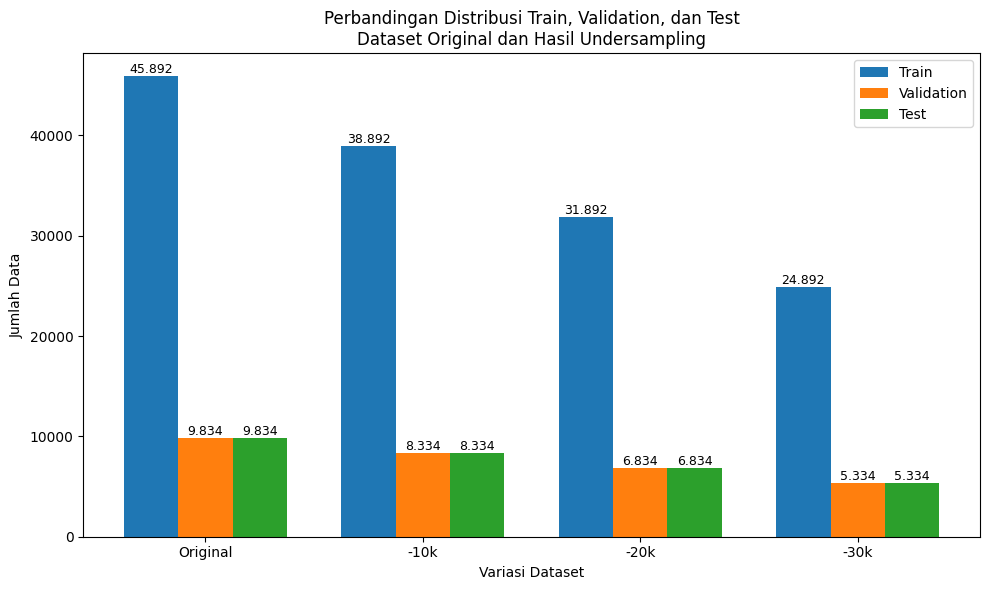

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# DATA SPLIT
# ===========================

datasets = ["Original", "-10k", "-20k", "-30k"]

train = np.array([45892, 38892, 31892, 24892])
val   = np.array([9834,  8334,  6834,  5334])
test  = np.array([9834,  8334,  6834,  5334])

# posisi bar
x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10,6))

# bar
bars_train = plt.bar(x - width, train, width, label="Train")
bars_val   = plt.bar(x,        val,   width, label="Validation")
bars_test  = plt.bar(x + width, test, width, label="Test")

# ===========================
# LABEL ANGKA DI ATAS BAR
# ===========================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        formatted = format(int(height), ',').replace(',', '.')
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            formatted,
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)

# ===========================
# LABEL Sumbu dan Judul
# ===========================
plt.xticks(x, datasets)
plt.xlabel("Variasi Dataset")
plt.ylabel("Jumlah Data")
plt.title("Perbandingan Distribusi Train, Validation, dan Test\nDataset Original dan Hasil Undersampling")

plt.legend()
plt.tight_layout()
plt.show()


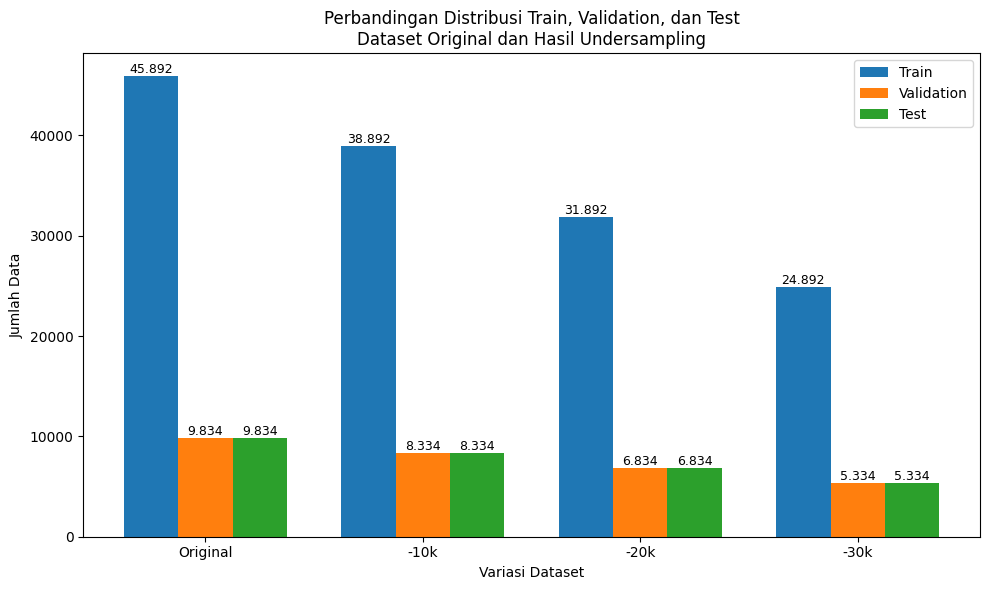

Gambar berhasil disimpan sebagai: distribusi_split_dataset.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# DATA SPLIT
# ===========================

datasets = ["Original", "-10k", "-20k", "-30k"]

train = np.array([45892, 38892, 31892, 24892])
val   = np.array([9834,  8334,  6834,  5334])
test  = np.array([9834,  8334,  6834,  5334])

# posisi bar
x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(10,6))

# bar
bars_train = plt.bar(x - width, train, width, label="Train")
bars_val   = plt.bar(x,        val,   width, label="Validation")
bars_test  = plt.bar(x + width, test, width, label="Test")

# ===========================
# LABEL ANGKA DI ATAS BAR
# ===========================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        formatted = format(int(height), ',').replace(',', '.')
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            formatted,
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars_train)
add_labels(bars_val)
add_labels(bars_test)

# ===========================
# LABEL Sumbu dan Judul
# ===========================
plt.xticks(x, datasets)
plt.xlabel("Variasi Dataset")
plt.ylabel("Jumlah Data")
plt.title("Perbandingan Distribusi Train, Validation, dan Test\nDataset Original dan Hasil Undersampling")

plt.legend()
plt.tight_layout()

# Save gambar
plt.savefig("distribusi_split_dataset.png", dpi=300)

plt.show()

print("Gambar berhasil disimpan sebagai: distribusi_split_dataset.png")
